In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.model_selection import train_test_split

df_stocks = pd.read_csv('../data/olist_engineered_stocks.csv')
features_stocks = ['sales_lag_1', 'sales_lag_2', 'sales_moving_avg_4', 'month']

X = df_stocks[features_stocks]
y = df_stocks['weekly_sales_volume']

# Pas de mélange (shuffle=False) car c'est une série temporelle !
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Dictionnaire pour récolter les erreurs à la fin
stock_scores = {}
print(f"Train set : {X_train.shape[0]} lignes | Test set : {X_test.shape[0]} lignes")

Train set : 22133 lignes | Test set : 5534 lignes


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)
preds_lr = lr.predict(X_test)

stock_scores['Régression Linéaire'] = {
    'MAE': mean_absolute_error(y_test, preds_lr),
    'RMSE': np.sqrt(mean_squared_error(y_test, preds_lr))
}
print("Régression Linéaire entraînée avec succès.")

Régression Linéaire entraînée avec succès.


In [5]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_test)

stock_scores['Random Forest'] = {
    'MAE': mean_absolute_error(y_test, preds_rf),
    'RMSE': np.sqrt(mean_squared_error(y_test, preds_rf))
}
print("Random Forest entraîné avec succès.")

Random Forest entraîné avec succès.


In [6]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
xgb.fit(X_train, y_train)
preds_xgb = xgb.predict(X_test)

stock_scores['XGBoost'] = {
    'MAE': mean_absolute_error(y_test, preds_xgb),
    'RMSE': np.sqrt(mean_squared_error(y_test, preds_xgb))
}
print("XGBoost entraîné avec succès.")

XGBoost entraîné avec succès.


=== TABLEAU DE PERFORMANCE DES MODÈLES DE STOCKS ===


,MAE,RMSE
Régression Linéaire,2.270333,4.610188
Random Forest,2.172653,4.379543
XGBoost,2.190940,4.438947


C:\Users\maell\AppData\Local\Temp\ipykernel_28340\643034144.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_perf.index, y=df_perf['MAE'], palette='muted')


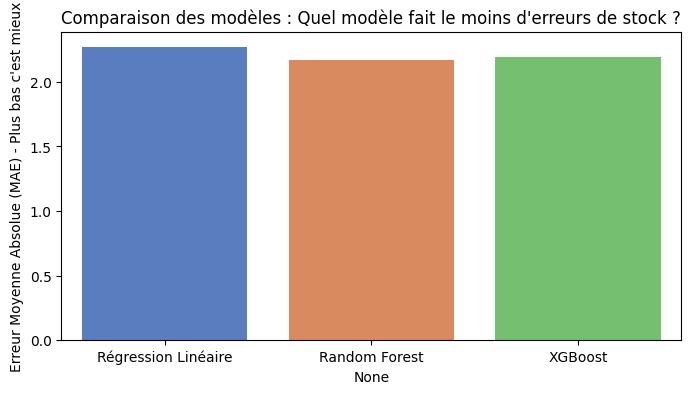

In [7]:
df_perf = pd.DataFrame(stock_scores).T

print("=== TABLEAU DE PERFORMANCE DES MODÈLES DE STOCKS ===")
display(df_perf) # Affiche un joli tableau propre dans le notebook

# Graphique de comparaison pour ton PDF
plt.figure(figsize=(8, 4))
sns.barplot(x=df_perf.index, y=df_perf['MAE'], palette='muted')
plt.ylabel('Erreur Moyenne Absolue (MAE) - Plus bas c\'est mieux')
plt.title('Comparaison des modèles : Quel modèle fait le moins d\'erreurs de stock ?')
plt.show()